# Predição de vendas | Deep Ice Cream (DIC)

## 1. Imports

In [446]:
# Gerais
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


# Modelos
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error

## 2. Carregamento dos Dados

In [282]:
fato = pd.read_csv('dados/dados_vendas.csv')
fato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID_PEDIDO     604 non-null    int64  
 1   DT_PEDIDO     604 non-null    object 
 2   ID_CLIENTE    604 non-null    int64  
 3   ESTADO        604 non-null    object 
 4   ID_PRODUTO    604 non-null    int64  
 5   NM_PRODUTO    604 non-null    object 
 6   ID_CATEG      604 non-null    int64  
 7   QTD           604 non-null    int64  
 8   VL_PRATICADO  604 non-null    float64
 9   TOTAL_ITEM    604 non-null    float64
dtypes: float64(2), int64(5), object(3)
memory usage: 47.3+ KB


In [283]:
fato['DT_PEDIDO'] = pd.to_datetime(fato['DT_PEDIDO'], format='%Y-%m-%d')

## 3. Modelagem ARIMA

### 3.1 Avaliação da Estacionariedade

In [286]:
base_temporal = (
    fato
    .set_index('DT_PEDIDO')
    .resample('W')['TOTAL_ITEM']
    .sum()
    .to_frame()
)

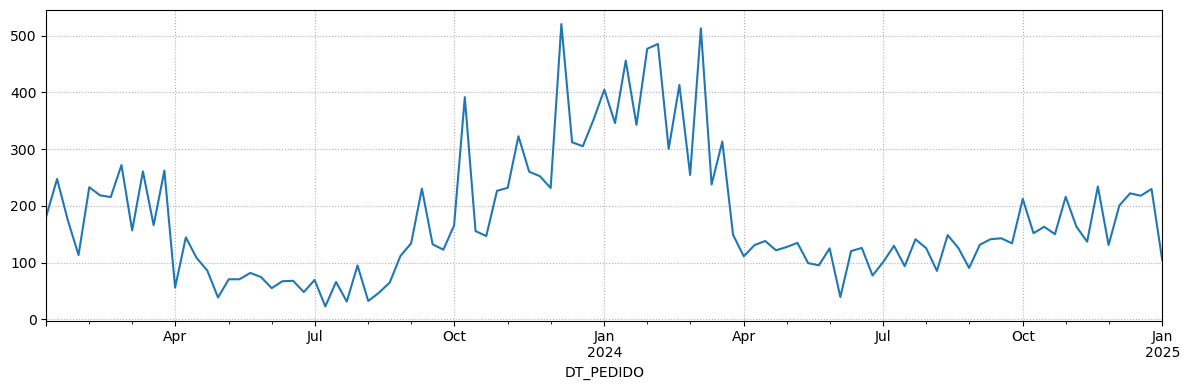

In [287]:
plt.figure(figsize=(12,4))
base_temporal['TOTAL_ITEM'].plot(legend=False)
plt.grid(linestyle=':')
plt.tight_layout()
plt.show()

Como observado na série temporal de vendas, os dados apresentam elevada variabilidade ao longo do período analisado, com oscilações frequentes entre as observações. Além disso, é possível notar mudanças no comportamento da série ao longo do tempo, sugerindo possíveis alterações na média e na variância. Esses aspectos indicam potenciais indícios de não estacionaridade, hipótese que será avaliada por meio do teste de Dickey-Fuller Aumentado (ADF).

---

In [289]:
teste_adf = adfuller(base_temporal['TOTAL_ITEM'])

f'Estatística ADF: {teste_adf[0]:.4f}', f'p-value: {teste_adf[1]:.4e}'

('Estatística ADF: -2.7034', 'p-value: 7.3450e-02')

Como o p-value é superior ao nível de significância de 5% (0,05), não há evidências suficientes para rejeitar a hipótese nula de presença de raiz unitária. Dessa forma, a série não pode ser considerada estacionária ao nível de significância adotado, sendo necessária a aplicação de técnicas de diferenciação antes do ajuste do modelo ARIMA.

---

### 3.2 Diferenciação de Primeira Ordem

In [292]:
serie_diff = base_temporal['TOTAL_ITEM'].diff().dropna()

In [293]:
teste_adf_diff = adfuller(serie_diff)
f'Estatística ADF: {teste_adf_diff[0]:.4f}', f'p-value: {teste_adf_diff[1]:.4e}'

('Estatística ADF: -2.9273', 'p-value: 4.2268e-02')

Após a aplicação da diferenciação de primeira ordem, o teste de Dickey-Fuller Aumentado apresentou estatística ADF de -2.93 e p-value de 0,042. Como o p-value é inferior ao nível de significância de 5% (0,05), rejeita-se a hipótese nula de presença de raiz unitária. Dessa forma, a série pode ser considerada estacionária para fins de modelagem, indicando que a diferenciação de primeira ordem foi suficiente para atender aos pressupostos do modelo ARIMA.

---

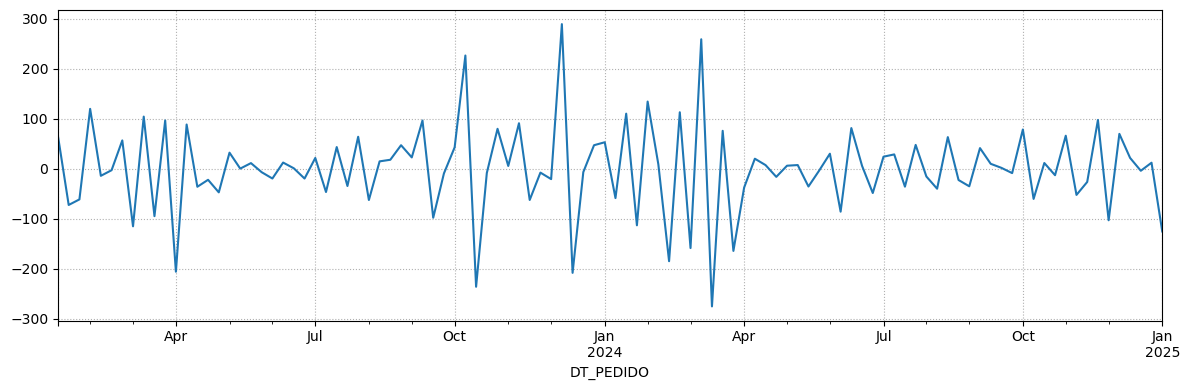

In [295]:
plt.figure(figsize=(12,4))
base_temporal['TOTAL_ITEM'].diff().dropna().plot(legend=False)
plt.grid(linestyle=':')
plt.tight_layout()
plt.show()

A série diferenciada apresenta oscilações em torno de uma média aproximadamente constante, sem tendência evidente ao longo do período analisado. Essa percepção visual é corroborada pelo teste ADF, que apresentou p-value inferior a 0.05, indicando que a diferenciação de primeira ordem foi suficiente para tornar a série estacionária para fins de modelagem ARIMA.

---

### 3.3 Determinação dos Parâmetros p e q

* MA(q)

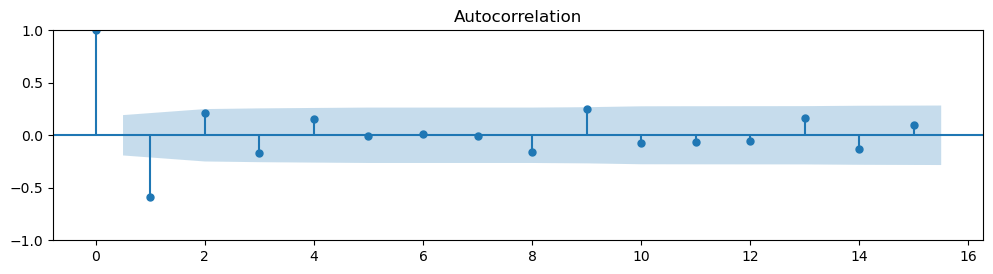

In [299]:
fig = plt.figure(figsize=(12,6))
ax1 = fig.add_subplot(211)
fig = plot_acf(base_temporal['TOTAL_ITEM'].diff().dropna(), lags=15, ax=ax1);


A análise da ACF indica que apenas o primeiro lag apresenta autocorrelação significativa. Como os demais lags permanecem dentro dos limites de confiança, será considerado inicialmente q = 1 para a componente de médias móveis (MA) do modelo ARIMA.

---

* Ar(p)

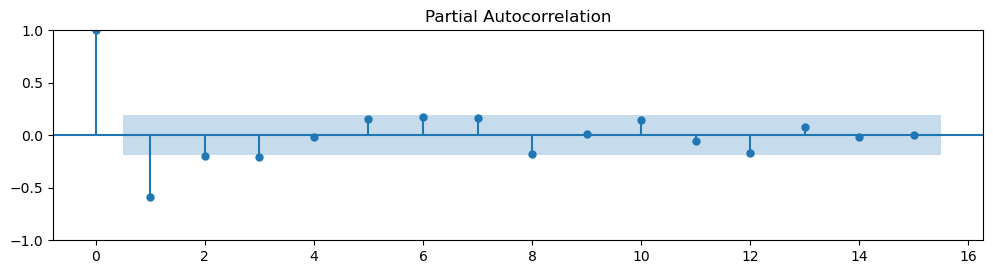

In [302]:
fig = plt.figure(figsize=(12,6))
ax1 = fig.add_subplot(211)
fig = plot_pacf(base_temporal['TOTAL_ITEM'].diff().dropna(), lags=15, ax=ax1);

A análise da PACF indica a existência de autocorrelações significativas nos primeiros lags da série diferenciada, sugerindo a presença de componentes autorregressivos (AR). Como não há um ponto de corte claramente definido, diferentes valores para o parâmetro p serão testados durante a etapa de modelagem, sendo selecionado o modelo que apresentar os melhores resultados.

---

### 3.4 Modelo ARIMA

In [305]:
# Separando treino e teste
teste_size = 12

treino = base_temporal.iloc[:-teste_size].copy()
teste = base_temporal.iloc[-teste_size:].copy()

In [306]:
dados_reais = teste['TOTAL_ITEM'].values

modelos = [
    (1,1,1),
    (2,1,1),
    (3,1,1),
    
    (1,1,0),
    (2,1,0),
    (3,1,0),
    
]
for i in modelos:
    modelo = ARIMA(treino['TOTAL_ITEM'], order=i).fit()
    
    predicao = modelo.forecast(steps=len(teste))
    
    mae = mean_absolute_error(dados_reais, predicao)
    rmse = np.sqrt(mean_squared_error(dados_reais, predicao))
    
    print(f'ARIMA{i} | AIC: {modelo.aic:.2f} | BIC: {modelo.bic:.2f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}')

ARIMA(1, 1, 1) | AIC: 1052.31 | BIC: 1059.87 | MAE: 39.58 | RMSE: 44.21
ARIMA(2, 1, 1) | AIC: 1054.29 | BIC: 1064.38 | MAE: 39.59 | RMSE: 44.20
ARIMA(3, 1, 1) | AIC: 1053.85 | BIC: 1066.46 | MAE: 38.56 | RMSE: 44.17
ARIMA(1, 1, 0) | AIC: 1055.65 | BIC: 1060.69 | MAE: 39.44 | RMSE: 43.12
ARIMA(2, 1, 0) | AIC: 1054.25 | BIC: 1061.82 | MAE: 39.89 | RMSE: 43.56
ARIMA(3, 1, 0) | AIC: 1051.85 | BIC: 1061.93 | MAE: 38.56 | RMSE: 44.17


Entre os modelos avaliados, o ARIMA(3,1,1) apresentou os menores valores de MAE e RMSE no conjunto de teste, indicando o melhor desempenho preditivo dentre os modelos analisados. Por esse motivo, ele foi selecionado para a etapa de avaliação e geração das previsões.

---

In [308]:
modelo_3_1_1 = ARIMA(treino['TOTAL_ITEM'], order=(3, 1, 1)).fit()

In [309]:
modelo_3_1_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             TOTAL_ITEM   No. Observations:                   93
Model:                 ARIMA(3, 1, 1)   Log Likelihood                -521.923
Date:                Tue, 09 Jun 2026   AIC                           1053.847
Time:                        08:57:26   BIC                           1066.456
Sample:                    01-08-2023   HQIC                          1058.936
                         - 10-13-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7429      0.477     -1.557      0.119      -1.678       0.192
ar.L2         -0.3436      0.336     -1.022      0.307      -1.002       0.315
ar.L3         -0.2165      0.105     -2.066      0.039      -0.422      -0.011
ma.L1         -0.0030      0.486     -0.006      0.995      -0.955       0.949
sigma2      4949.9383    499.321      9.913      0.000    3971.286    5928.590
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                29.22
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               1.48   Skew:                             0.49
Prob(H) (two-sided):                  0.28   Kurtosis:                         5.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

---

O modelo ARIMA(3,1,1) apresentou um ajuste satisfatório para a série analisada, sendo capaz de representar parte dos padrões temporais observados nos dados. Os resíduos não apresentaram evidências de autocorrelação (Ljung-Box p-value = 0,95) nem de problemas relacionados à variância ao longo do tempo (p-value = 0,28), indicando um comportamento adequado para fins de previsão. Entretanto, os resíduos não apresentaram distribuição normal segundo o teste de Jarque-Bera, sugerindo que ainda existem variações na série que não foram totalmente explicadas pelo modelo.

---

In [311]:
predicao = modelo_3_1_1.forecast(
    steps=len(teste)
)


In [312]:
comparacao = teste.copy()
comparacao['PREDITO'] = (predicao.values).round(1)
comparacao.head(5)

,TOTAL_ITEM,PREDITO
DT_PEDIDO,,
2024-10-20,163.1,171.7
2024-10-27,150.0,160.7
2024-11-03,215.9,175.2
2024-11-10,163.4,163.9
2024-11-17,136.8,169.7


### 3.5 Avaliação do modelo ARIMA

In [314]:
dados_reais = teste['TOTAL_ITEM'].values

In [315]:
mae = mean_absolute_error(dados_reais, predicao)
rmse = np.sqrt(mean_squared_error(dados_reais, predicao))
mape = mean_absolute_percentage_error(dados_reais, predicao) * 100

f'MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%'

'MAE: 38.56 | RMSE: 44.17 | MAPE: 22.14%'

---

O modelo ARIMA(3,1,1) apresentou MAE de 38,56, RMSE de 44,17 e MAPE de 22,14%, indicando um desempenho razoável na previsão das vendas semanais. Conforme observado no gráfico, as previsões acompanharam o nível médio da série durante o período de teste, porém apresentaram dificuldade em reproduzir as oscilações mais acentuadas observadas nos dados reais. Ainda assim, o modelo foi capaz de fornecer estimativas consistentes para o comportamento geral da série, servindo como uma base adequada para comparação com modelos mais complexos.

---

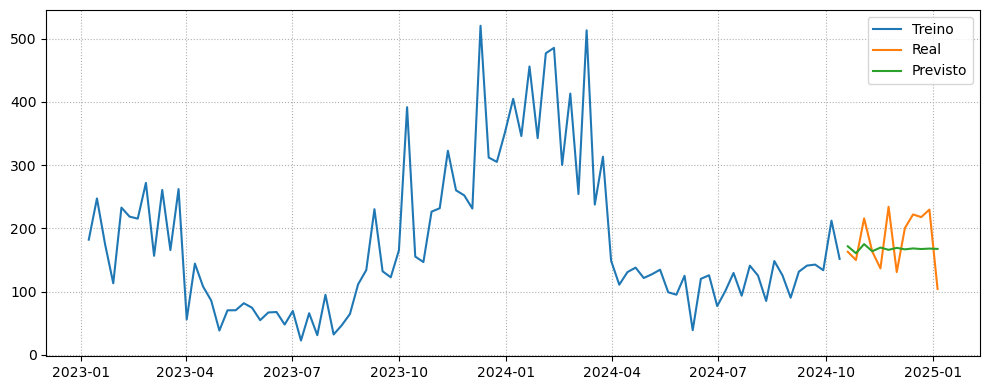

In [317]:
plt.figure(figsize=(10,4))

plt.plot(treino.index, treino['TOTAL_ITEM'], label='Treino')
plt.plot(teste.index, teste['TOTAL_ITEM'], label='Real')
plt.plot(teste.index, predicao, label='Previsto')
plt.grid(linestyle=':')
plt.tight_layout()
plt.legend()
plt.show()

Apesar dos resultados satisfatórios obtidos pelo modelo ARIMA(3,1,1), observa-se que as previsões tendem a suavizar as variações da série, não capturando integralmente os picos e quedas observados nas vendas semanais. Esse comportamento sugere a possível existência de componentes sazonais que não são considerados pelo ARIMA tradicional. Dessa forma, será avaliada a aplicação do modelo SARIMA, que incorpora parâmetros sazonais e pode representar de maneira mais adequada padrões recorrentes ao longo do tempo, buscando melhorar a capacidade preditiva da série.

---

#### Conclusão ARIMA

O modelo ARIMA(3,1,1) apresentou desempenho satisfatório na previsão das vendas semanais, obtendo MAE de 38,56, RMSE de 44,17 e MAPE de 22,14%. Embora as previsões não tenham conseguido reproduzir integralmente os picos e quedas observados na série, o modelo foi capaz de acompanhar o comportamento geral dos dados e gerar estimativas consistentes para o período de teste. Esses resultados indicam que o ARIMA representa adequadamente a dinâmica temporal da série, servindo como referência para comparação com modelos mais complexos.

---

## 4. Modelagem SARIMA

### Criando modelo SARIMA

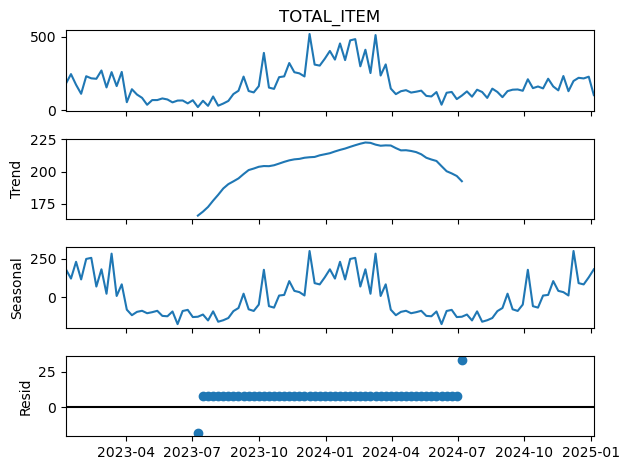

In [323]:
decomp = seasonal_decompose(
    base_temporal['TOTAL_ITEM'],
    model='additive',
    period=52
)

decomp.plot()
plt.tight_layout()
plt.show()

A decomposição da série mostra a presença de uma tendência ao longo do período analisado, com crescimento das vendas até o início de 2024 e posterior redução. Embora exista variação ao longo do tempo, não foi identificado um padrão sazonal fortemente definido. Dessa forma, a decomposição sugere que a série apresenta componentes temporais relevantes, que serão considerados na avaliação do modelo SARIMA.

---

In [325]:
modelos_sarima = [
    ((3,1,1), (1,0,0,52)),
    ((3,1,0), (1,0,0,52)),
    ((1,1,0), (1,0,0,52)),
    ((3,1,1), (0,1,0,52)),
    ((3,1,1), (1,1,0,52))
]

for order, seasonal_order in modelos_sarima:
    modelo = SARIMAX(
        treino['TOTAL_ITEM'],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    predicao = modelo.forecast(steps=len(teste))

    mae = mean_absolute_error(dados_reais, predicao)
    rmse = np.sqrt(mean_squared_error(dados_reais, predicao))

    print(
        f'SARIMA{order}x{seasonal_order} | '
        f'AIC: {modelo.aic:.2f} | '
        f'BIC: {modelo.bic:.2f} | '
        f'MAE: {mae:.2f} | '
        f'RMSE: {rmse:.2f}'
    )

SARIMA(3, 1, 1)x(1, 0, 0, 52) | AIC: 419.92 | BIC: 429.59 | MAE: 48.63 | RMSE: 61.63
SARIMA(3, 1, 0)x(1, 0, 0, 52) | AIC: 418.11 | BIC: 426.16 | MAE: 48.09 | RMSE: 59.98
SARIMA(1, 1, 0)x(1, 0, 0, 52) | AIC: 436.86 | BIC: 441.85 | MAE: 46.89 | RMSE: 57.14
SARIMA(3, 1, 1)x(0, 1, 0, 52) | AIC: 426.00 | BIC: 434.06 | MAE: 88.06 | RMSE: 118.13
SARIMA(3, 1, 1)x(1, 1, 0, 52) | AIC: 12.00 | BIC: nan | MAE: 87.15 | RMSE: 117.43


---

Foram avaliadas diferentes configurações do modelo SARIMA considerando uma sazonalidade anual de 52 semanas. Entre os modelos testados, o SARIMA(3,1,0)(1,0,0,52) apresentou os menores valores de AIC e BIC, indicando o melhor ajuste entre os modelos sazonais avaliados. Entretanto, os valores de MAE e RMSE permaneceram elevados quando comparados aos resultados obtidos com o modelo ARIMA, sugerindo que a inclusão do componente sazonal não resultou em melhorias significativas na capacidade preditiva da série. Além disso, os modelos com diferenciação sazonal (D=1) apresentaram desempenho inferior, indicando que a sazonalidade anual não representa adequadamente o comportamento dos dados analisados.

---

In [327]:
modelo_sarima = SARIMAX(
        treino['TOTAL_ITEM'],
        order=(3, 1, 0),
        seasonal_order=(1, 0, 0, 52),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
predicao_sarima = modelo_sarima.forecast(steps=len(teste))

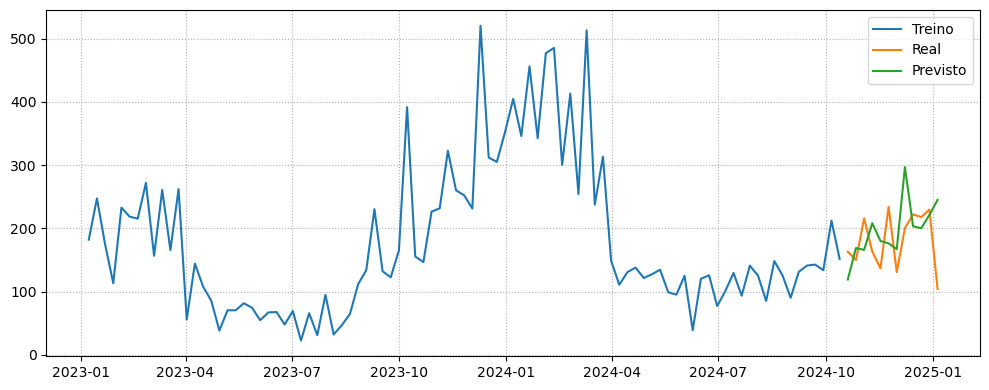

In [328]:
plt.figure(figsize=(10,4))

plt.plot(treino.index, treino['TOTAL_ITEM'], label='Treino')
plt.plot(teste.index, teste['TOTAL_ITEM'], label='Real')
plt.plot(teste.index, predicao_sarima, label='Previsto')
plt.grid(linestyle=':')
plt.tight_layout()
plt.legend()
plt.show()

Conforme observado no gráfico, o modelo SARIMA foi capaz de acompanhar parcialmente o comportamento geral da série durante o período de teste. Entretanto, as previsões apresentaram oscilações mais acentuadas e maior distanciamento dos valores reais quando comparadas às previsões obtidas pelo modelo ARIMA. Em diversos momentos, o modelo superestimou ou subestimou as vendas observadas, resultando em erros mais elevados.

#### Conclusão SARIMA

Apesar da inclusão do componente sazonal e da avaliação de diferentes configurações do modelo SARIMA, os resultados obtidos não apresentaram melhora na capacidade preditiva da série. As métricas de desempenho, como MAE e RMSE, foram superiores às observadas para o modelo ARIMA(3,1,1), indicando previsões menos precisas. Dessa forma, conclui-se que a incorporação da sazonalidade não trouxe ganhos relevantes para o problema estudado. Considerando o melhor desempenho preditivo, a simplicidade e a maior estabilidade dos resultados, o modelo ARIMA(3,1,1) foi mantido como a alternativa mais adequada para representar e prever o comportamento da série temporal analisada.

## Random Forest

---

Criando lags para o random forest

In [450]:
rf = base_temporal.copy()
for lag in range(1,13):
    rf[f'lag_{lag}'] = rf['TOTAL_ITEM'].shift(lag)

In [452]:
rf.dropna(inplace=True)

---

Extraindo informações da data


In [455]:
rf['MES'] = rf.index.month

rf['trimestre'] = rf.index.quarter

rf['semana_ano'] = rf.index.isocalendar().week.astype(int)

In [457]:
rf.head(1)

,TOTAL_ITEM,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,MES,trimestre,semana_ano
DT_PEDIDO,,,,,,,,,,,,,,,,
2023-04-02,56.1,262.2,165.8,260.8,156.7,272.0,215.5,218.6,232.9,113.3,174.8,247.4,182.2,4,2,13


---

Média móvel

In [460]:
rf['media_4'] = (
    rf['TOTAL_ITEM']
    .rolling(4)
    .mean()
)
rf['media_8'] = (
    rf['TOTAL_ITEM']
    .rolling(8)
    .mean()
)

---

Separando treino e teste

In [463]:
teste_size = 12

treino = rf.iloc[:-teste_size]
teste = rf.iloc[-teste_size:]

---

Definindo X e Y

In [466]:
X_train = treino.drop(
    columns='TOTAL_ITEM'
)

y_train = treino['TOTAL_ITEM']

X_test = teste.drop(
    columns='TOTAL_ITEM'
)

y_test = teste['TOTAL_ITEM']

---
 
Treinando modelo

In [473]:
modelo_flo = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    random_state=77
)
modelo_flo.fit(
    X_train,
    y_train
)

,n_estimators,500
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


---

Predição

In [478]:
predicao = modelo_flo.predict(
    X_test
)

---

Avaliação do modelo

In [484]:
mae = mean_absolute_error(y_test,predicao)

rmse = np.sqrt(mean_squared_error(y_test,predicao))

mape = (mean_absolute_percentage_error(y_test,predicao) * 100)

print(f'MAE: {mae:.2f}')

print(f'RMSE: {rmse:.2f}')

print(f'MAPE: {mape:.2f}%')

MAE: 31.43
RMSE: 39.57
MAPE: 21.60%


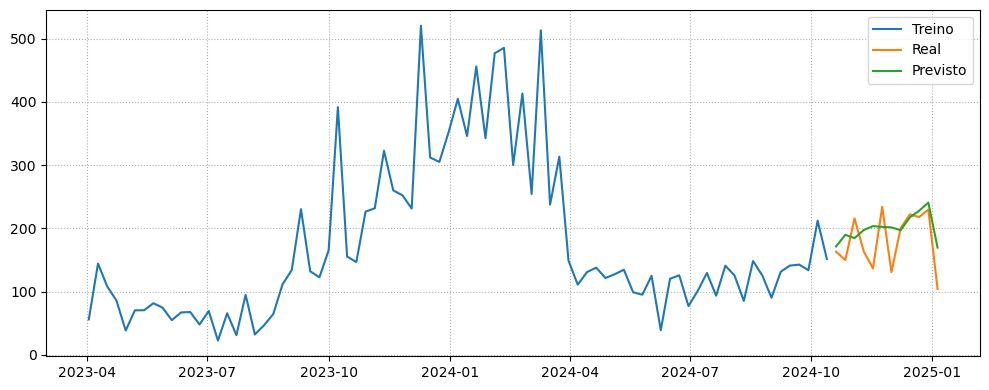

In [486]:
plt.figure(figsize=(10,4))

plt.plot(
    treino.index,
    treino['TOTAL_ITEM'],
    label='Treino'
)

plt.plot(
    y_test.index,
    y_test,
    label='Real'
)

plt.plot(
    y_test.index,
    predicao,
    label='Previsto'
)

plt.legend()

plt.grid(linestyle=':')

plt.tight_layout()

plt.show()